<a href="https://colab.research.google.com/github/BridgingAISocietySummerSchools/Python-for-Data-Science-Workshop/blob/main/02_advanced_self_learning/07_pandas_essentials.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📓 Notebook 7 — Pandas Essentials

> **Advanced & Self-Learning Track — Notebook 7 of 14** · **Estimated time:** 45–55 min · **Difficulty:** Beginner
>
> This track is the self-paced deep-dive of the course. If you are looking for the 90-minute live **Introduction Session**, it lives in [`01_introduction/`](../01_introduction/).

### 🔗 Building on Track 1

The 90-minute live Introduction Session took a first tour of pandas in [`../01_introduction/05_pandas_intro.ipynb`](../01_introduction/05_pandas_intro.ipynb): DataFrames, `pd.read_csv()`, the inspection quartet `.head()` / `.shape` / `.info()` / `.describe()`, selecting a column, filtering rows, a computed column, one `groupby`, and one chart. This notebook is the full treatment of the same material — it adds `.loc` vs `.iloc`, multi-condition boolean masks, `value_counts`, richer `groupby` aggregation, writing CSV, reading it from a real path, and plotting straight from a DataFrame. A cold start is fine: nothing below assumes you attended the live session.

You can do real data work in pure Python — we did exactly that in Notebooks 3 and 4. But once your data is more than a few rows, you want a **proper table**: row + column labels, fast filtering, group-by operations, reading and writing CSV files. That is **pandas**.

Pandas is *the* library data scientists touch every single day, and this is the track's main pandas notebook: by the end of it you can load a tabular dataset, select and filter it, derive new columns, aggregate it by category, and plot the result. Two follow-up notebooks then build directly on it — **Notebook 8, [Data Cleaning and Preprocessing](08_data_cleaning_preprocessing.ipynb)**, handles missing values, duplicates, type conversion, and merging, and **Notebook 10, [Exploratory Data Analysis](10_exploratory_data_analysis.ipynb)**, turns these mechanics into a systematic way of interrogating a new dataset. You will use pandas in every notebook from here on.

## 🎯 Learning objectives

1. Understand the two pandas data structures — **Series** and **DataFrame**.
2. Create DataFrames from dictionaries, from **lists of dicts** (the shape of Notebook 4), and from CSV data.
3. Inspect data with `head()`, `tail()`, `info()`, `describe()`, `shape`, `dtypes`.
4. Select **rows** by label (`.loc`) and by position (`.iloc`) — and know why the two disagree.
5. Filter with reusable **boolean masks**, combined with `&`, `|` and `~`.
6. Add and modify columns.
7. Compute summary statistics and `groupby` aggregations.
8. Make a quick exploratory plot directly from a DataFrame.

## ✅ Prerequisites

Notebooks 1–6 of this track: lists, dictionaries, comprehensions and lists of dicts (Notebooks 3–4), functions and imports ([`05_functions_and_modules.ipynb`](05_functions_and_modules.ipynb)), and NumPy arrays, boolean masks and vectorised arithmetic ([`06_numpy_fundamentals.ipynb`](06_numpy_fundamentals.ipynb)) — pandas is built on top of those, and it shows.

⬅️ **Previous:** [`06_numpy_fundamentals.ipynb`](06_numpy_fundamentals.ipynb) · ➡️ **Next:** [`08_data_cleaning_preprocessing.ipynb`](08_data_cleaning_preprocessing.ipynb)

## 1. The pandas mental model

Pandas has two core objects — and both are, quite literally, the NumPy arrays from Notebook 6 with labels bolted on:

| Object        | Conceptually          | Compare to                        |
|---------------|-----------------------|-----------------------------------|
| `Series`      | A single column       | a labelled NumPy 1-D array        |
| `DataFrame`   | A whole table         | a labelled 2-D array / SQL table  |

```
   ┌────────────────  DataFrame  ────────────────┐
   │  name       age   score    city            │
   ├─────────────────────────────────────────────┤
0  │  Alice      25    87.5     Berlin          │   ← row 0
1  │  Bob        30    91.0     Munich          │
2  │  Charlie    27    79.2     Hamburg         │
   └─────────────────────────────────────────────┘
       column   column column   column           ← each column is a Series
```

In [1]:
# The standard import alias — you'll see "pd" in every pandas-using notebook ever
import pandas as pd
import numpy as np

print(f"pandas version: {pd.__version__}")
print(f"numpy  version: {np.__version__}")

pandas version: 2.3.3
numpy  version: 2.0.2


## 2. Creating a DataFrame

### From a dictionary of lists

The most natural way to build a small DataFrame by hand is from a `dict` whose **keys are column names** and whose **values are lists** (one entry per row).

*A pandas tip:* inside Jupyter, just typing the variable name (`df`) as the last line of a cell renders a properly formatted HTML table — much nicer than `print(df)`. Try both.


In [2]:
data = {
    "name":  ["Alice", "Bob", "Charlie", "Diana", "Eve", "Frank"],
    "age":   [25, 30, 27, 35, 22, 41],
    "score": [87.5, 91.0, 79.2, 94.3, 68.7, 82.1],
    "city":  ["Berlin", "Munich", "Hamburg", "Berlin", "Munich", "Hamburg"],
}

df = pd.DataFrame(data)
df

,name,age,score,city
0,Alice,25,87.5,Berlin
1,Bob,30,91.0,Munich
2,Charlie,27,79.2,Hamburg
3,Diana,35,94.3,Berlin
4,Eve,22,68.7,Munich
5,Frank,41,82.1,Hamburg


### …and from a list of dicts

Notebook 4 ([`04_dictionaries_advanced.ipynb`](04_dictionaries_advanced.ipynb)) argued that a **list of dictionaries** — one dict per row, column names as keys — is the shape almost all real data arrives in: it is what web APIs send and what CSV readers produce internally. It also promised that pandas turns that shape into a table in a single call, and does the grouping you wrote by hand there in one line. Here is the payoff.


In [3]:
# The exact list of dicts from Notebook 4 — one dictionary per row
employees = [
    {"name": "Alice",   "department": "Engineering", "salary": 75000},
    {"name": "Bob",     "department": "Marketing",   "salary": 65000},
    {"name": "Charlie", "department": "Engineering", "salary": 80000},
    {"name": "Diana",   "department": "Sales",       "salary": 60000},
    {"name": "Eve",     "department": "Engineering", "salary": 90000},
    {"name": "Frank",   "department": "Marketing",   "salary": 70000},
]

# Keys become column names, dicts become rows. That is the whole conversion.
emp = pd.DataFrame(employees)
print(emp)

# In Notebook 4, "average salary by department" needed a defaultdict, a loop and
# a formatted print. Here it is one line — and it is the same answer
# (Engineering 81,667 / Marketing 67,500 / Sales 60,000):
print("\nAverage salary by department:")
print(emp.groupby("department")["salary"].mean())


      name   department  salary
0    Alice  Engineering   75000
1      Bob    Marketing   65000
2  Charlie  Engineering   80000
3    Diana        Sales   60000
4      Eve  Engineering   90000
5    Frank    Marketing   70000

Average salary by department:
department
Engineering    81666.666667
Marketing      67500.000000
Sales          60000.000000
Name: salary, dtype: float64


## 3. Inspecting a DataFrame

Whenever you load a new dataset, run these inspection commands first. They tell you the *shape*, the *types*, and the *typical values* before you do anything else.

In [4]:
print("Shape (rows, cols):", df.shape)
print("\nColumn names :", df.columns.tolist())
print("\nIndex        :", df.index.tolist())
print("\nData types:")
print(df.dtypes)

Shape (rows, cols): (6, 4)

Column names : ['name', 'age', 'score', 'city']

Index        : [0, 1, 2, 3, 4, 5]

Data types:
name      object
age        int64
score    float64
city      object
dtype: object


In [5]:
# The first / last few rows
print("--- head(3) ---")
print(df.head(3))

print("\n--- tail(2) ---")
print(df.tail(2))

--- head(3) ---
      name  age  score     city
0    Alice   25   87.5   Berlin
1      Bob   30   91.0   Munich
2  Charlie   27   79.2  Hamburg

--- tail(2) ---
    name  age  score     city
4    Eve   22   68.7   Munich
5  Frank   41   82.1  Hamburg


In [6]:
# Quick statistical summary for numeric columns
df.describe()

,age,score
count,6.0000,6.000000
mean,30.0000,83.800000
std,6.9857,9.250297
min,22.0000,68.700000
25%,25.5000,79.925000
50%,28.5000,84.800000
75%,33.7500,90.125000
max,41.0000,94.300000


In [7]:
# Schema / non-null counts — the single most useful command on a new dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    6 non-null      object 
 1   age     6 non-null      int64  
 2   score   6 non-null      float64
 3   city    6 non-null      object 
dtypes: float64(1), int64(1), object(2)
memory usage: 320.0+ bytes


**How to read those two outputs.** `.describe()` covers only the *numeric* columns, and its `count` row counts **non-missing** values — a count lower than `df.shape[0]` is your first hint that data is missing. `.info()` says the same thing from the other side: here every column reports `6 non-null` out of 6 rows, with sensible dtypes (`int64` for whole numbers, `float64` for decimals, `object` for text).

Clean is the exception, not the rule. On real data `.info()` is where you discover that a `price` column arrived as `object` because someone typed `1.200,00`, or that a third of `age` is missing. Everything in *this* notebook is deliberately clean so that the mechanics stay visible; repairing messy data is [Notebook 8](08_data_cleaning_preprocessing.ipynb)'s job.


## 4. Selecting columns

These three patterns appear in every pandas notebook:

```python
df["score"]              # one column  → Series
df[["name", "score"]]    # several columns → DataFrame   (note the double brackets)
df.score                 # attribute-style shortcut
```

The double brackets are not special syntax: the inner brackets are an ordinary **list of column names** handed to `df[...]`, which is why the result keeps its table shape while `df["score"]` collapses to a single Series.

`df.score` saves keystrokes, but use it knowingly: it only works when the column name is a valid Python identifier (no spaces, no `-`, not starting with a digit), it silently resolves to the *method* instead of your column when a column is named something like `count`, `min` or `shape`, and it **cannot create** a column — `df.new = ...` quietly sets an attribute and no column appears. Brackets always work; prefer them in code you keep.


In [8]:
# One column → Series
scores = df["score"]
print(scores)
print(f"\ntype: {type(scores).__name__}")

0    87.5
1    91.0
2    79.2
3    94.3
4    68.7
5    82.1
Name: score, dtype: float64

type: Series


In [9]:
# Several columns → DataFrame
subset = df[["name", "score", "city"]]
subset

,name,score,city
0,Alice,87.5,Berlin
1,Bob,91.0,Munich
2,Charlie,79.2,Hamburg
3,Diana,94.3,Berlin
4,Eve,68.7,Munich
5,Frank,82.1,Hamburg


## 5. Selecting rows — `.loc` vs `.iloc`

The live session skipped this on purpose, because it is the one piece of pandas that reliably trips people up. The whole idea fits on one line:

> **`.loc` looks things up by *label*. `.iloc` looks things up by *integer position*** — the `i` stands for integer.

Why does anyone get confused, then? Because with the default index the labels *are* `0, 1, 2, …`, so `df.loc[2]` and `df.iloc[2]` return the same row and the distinction looks like pedantry. It stops looking like pedantry the moment the index is something other than a row counter — so let's make one with `set_index()`.


In [10]:
# set_index promotes an existing column to be the row labels
students = df.set_index("name")
students


,age,score,city
name,,,
Alice,25,87.5,Berlin
Bob,30,91.0,Munich
Charlie,27,79.2,Hamburg
Diana,35,94.3,Berlin
Eve,22,68.7,Munich
Frank,41,82.1,Hamburg


In [11]:
# Right now, the label "Charlie" and the position 2 point at the same row:
print("loc['Charlie'] and iloc[2] are the same row?",
      students.loc["Charlie"].equals(students.iloc[2]))

# Now re-order the table. Labels travel with their rows; positions do not.
by_score = students.sort_values("score", ascending=False)
print("\nSame table, sorted by score:")
print(by_score)

print("\nAfter sorting:")
print(f"  by_score.loc['Charlie'] -> {by_score.loc['Charlie'].name:<8} (still Charlie)")
print(f"  by_score.iloc[2]        -> {by_score.iloc[2].name:<8} (position 2 is now someone else!)")


loc['Charlie'] and iloc[2] are the same row? True

Same table, sorted by score:
         age  score     city
name                        
Diana     35   94.3   Berlin
Bob       30   91.0   Munich
Alice     25   87.5   Berlin
Frank     41   82.1  Hamburg
Charlie   27   79.2  Hamburg
Eve       22   68.7   Munich

After sorting:
  by_score.loc['Charlie'] -> Charlie  (still Charlie)
  by_score.iloc[2]        -> Alice    (position 2 is now someone else!)


In [12]:
# The second surprise: a LABEL slice includes its endpoint...
by_label = students.loc["Alice":"Charlie", ["age", "score"]]
print(f"students.loc['Alice':'Charlie'] -> {len(by_label)} rows")
print(by_label)

# ...while a POSITION slice excludes it, exactly like a Python list.
by_pos = students.iloc[0:2, [0, 1]]
print(f"\nstudents.iloc[0:2]              -> {len(by_pos)} rows")
print(by_pos)

# Alice, Bob and Charlie sit at positions 0, 1, 2 — so the position-equivalent
# of that label slice needs a 3, not a 2:
print(f"\nstudents.iloc[0:3]              -> {len(students.iloc[0:3])} rows  (now it matches)")


students.loc['Alice':'Charlie'] -> 3 rows
         age  score
name               
Alice     25   87.5
Bob       30   91.0
Charlie   27   79.2

students.iloc[0:2]              -> 2 rows
       age  score
name             
Alice   25   87.5
Bob     30   91.0

students.iloc[0:3]              -> 3 rows  (now it matches)


> 🎯 **How to remember it**
>
> |                          | `.loc`                                | `.iloc`                          |
> |--------------------------|---------------------------------------|----------------------------------|
> | indexes by               | **labels** (whatever is in the index) | **integer positions** (0, 1, 2, …) |
> | slice endpoint           | **included**                          | **excluded**                     |
> | survives `sort_values()` | yes — labels follow their rows        | no — it means "whatever is n-th now" |
>
> The endpoint rule is not pandas being awkward. `"Alice":"Charlie"` is a **name range**, and a human who says "Alice through Charlie" means Charlie included. `0:3` is a **count**, and Python counts have always been half-open (`range(0, 3)`, `my_list[0:3]`).
>
> **In practice:** default to `.loc`. It keeps saying what you meant after the rows get sorted, filtered or reindexed — and it takes rows *and* columns in one call, as you'll see with masks in a moment. Reach for `.iloc` only when you genuinely mean "the *n*-th row", e.g. `df.iloc[0]` for "whatever happens to be first".


## 6. Filtering — the boolean-mask idiom

This is **the** pattern of pandas, and it is the NumPy masking from Notebook 6 with labels attached: build a Series of `True`/`False` values that says which rows you want, then index the DataFrame with it.

```python
df[ df["score"] > 85 ]
   └─────────────┘
   boolean Series, one entry per row of df
```

A mask is an ordinary object, so it is worth giving it a name: you can print it, count it with `.sum()`, negate it with `~`, and reuse it in several places instead of retyping the condition.

> ⚠️ Two stumbles that catch everybody once:
> - Use **`&`, `|`, `~`** — *not* `and` / `or` / `not`. The Python keywords ask for a single true/false answer and raise `ValueError` on a whole Series.
> - **Wrap each condition in parentheses.** `&` and `|` bind more tightly than `>` and `==`, so `df["a"] > 1 & df["b"] < 2` parses as something you did not mean.


In [13]:
# Step 1: see the mask
mask = df["score"] > 85
print("Mask:")
print(mask)
print()

# Step 2: apply it
print("High scorers:")
print(df[mask])

Mask:
0     True
1     True
2    False
3     True
4    False
5    False
Name: score, dtype: bool

High scorers:
    name  age  score    city
0  Alice   25   87.5  Berlin
1    Bob   30   91.0  Munich
3  Diana   35   94.3  Berlin


In [14]:
# Combining conditions — parentheses around each part, and & (not "and")
high_and_young = df[(df["score"] > 80) & (df["age"] < 30)]
print("Score > 80 AND age < 30:")
print(high_and_young)

# OR uses |
in_berlin_or_top = df[(df["city"] == "Berlin") | (df["score"] > 90)]
print("\nBerlin OR top scorer:")
print(in_berlin_or_top)

# ~ flips a mask: "everyone who is NOT a high scorer". Note we reuse `mask`
# from the cell above rather than retyping the condition.
print("\nNOT high scorers, i.e. df[~mask]:")
print(df[~mask])
print(f"\nhigh scorers: {mask.sum()} of {len(df)}")

# And this is the .loc form: rows chosen by mask, columns chosen by label
print("\ndf.loc[mask, ['name', 'score']]:")
print(df.loc[mask, ["name", "score"]])


Score > 80 AND age < 30:
    name  age  score    city
0  Alice   25   87.5  Berlin

Berlin OR top scorer:
    name  age  score    city
0  Alice   25   87.5  Berlin
1    Bob   30   91.0  Munich
3  Diana   35   94.3  Berlin

NOT high scorers, i.e. df[~mask]:
      name  age  score     city
2  Charlie   27   79.2  Hamburg
4      Eve   22   68.7   Munich
5    Frank   41   82.1  Hamburg

high scorers: 3 of 6

df.loc[mask, ['name', 'score']]:
    name  score
0  Alice   87.5
1    Bob   91.0
3  Diana   94.3


## 7. Adding and modifying columns

Assigning to a column name that does not exist **creates** it; assigning to one that does **overwrites** it. The right-hand side is a whole Series, so the arithmetic is vectorised — the NumPy idea from Notebook 6, with no loop in sight.

The third example uses **`pd.cut()`**, which turns a numeric column into a small set of labelled bins — here a score becomes a letter grade. You give it the cut points and one label per interval: six cut points make five intervals, hence five labels. The result is a *categorical* column, which is exactly the right type to group by later.


In [15]:
# Add a column from a formula
df["score_pct"] = df["score"] / 100

# Add a boolean column from a comparison
df["passed"] = df["score"] >= 70

# A conditional / categorical column
df["grade"] = pd.cut(
    df["score"],
    bins=[0, 60, 70, 80, 90, 100],
    labels=["F", "D", "C", "B", "A"],
)

# Sorted by score, so the grade boundaries are easy to check by eye
print(df.sort_values("score", ascending=False)[["name", "score", "grade"]].to_string(index=False))

df

   name  score grade
  Diana   94.3     A
    Bob   91.0     A
  Alice   87.5     B
  Frank   82.1     B
Charlie   79.2     C
    Eve   68.7     D


,name,age,score,city,score_pct,passed,grade
0,Alice,25,87.5,Berlin,0.875,True,B
1,Bob,30,91.0,Munich,0.910,True,A
2,Charlie,27,79.2,Hamburg,0.792,True,C
3,Diana,35,94.3,Berlin,0.943,True,A
4,Eve,22,68.7,Munich,0.687,False,D
5,Frank,41,82.1,Hamburg,0.821,True,B


## 8. Summary statistics & `value_counts`

In [16]:
print("Score stats:")
print(f"  mean   : {df['score'].mean():.2f}")
print(f"  median : {df['score'].median():.2f}")
print(f"  std    : {df['score'].std():.2f}")
print(f"  min    : {df['score'].min():.2f}")
print(f"  max    : {df['score'].max():.2f}")

print("\nHow many people in each city:")
print(df["city"].value_counts())

Score stats:
  mean   : 83.80
  median : 84.80
  std    : 9.25
  min    : 68.70
  max    : 94.30

How many people in each city:
city
Berlin     2
Munich     2
Hamburg    2
Name: count, dtype: int64


## 9. `groupby` — the most useful pandas verb

`groupby` answers "what is the *something* of *something else*, broken down by *category*?" — "average score by city", "total revenue per region", "number of customers per year". It is the one-line version of the hand-written grouping loop from Notebook 4.

The mental model is **split → apply → combine**, and for the table above it is literally this:

```
  split by "city"                        apply .mean()      combine
  ───────────────────────────────        ─────────────      ─────────────────────
  Berlin  → Alice 87.5, Diana 94.3   →      90.90       ┐   city
  Hamburg → Charlie 79.2, Frank 82.1 →      80.65       ├→  Berlin     90.90
  Munich  → Bob 91.0, Eve 68.7       →      79.85       ┘   Hamburg    80.65
                                                            Munich     79.85
```

Note the group order: pandas returns groups **sorted by key** (Berlin, Hamburg, Munich), not in the order they first appear in the data. And note that the result is a **Series indexed by city** — the grouping column has become the index, which is why `.loc["Berlin"]` works on it.


In [17]:
# The "split" is a real thing you can inspect: a GroupBy object knows which
# rows belong to which key, before any aggregation happens.
groups = df.groupby("city")
print("Row labels per group:", {city: rows.tolist() for city, rows in groups.groups.items()})

# You can even walk the groups yourself — this is the loop groupby saves you
# from writing (compare it with the defaultdict version in Notebook 4).
for city, group in groups:
    print(f"\n--- {city} ({len(group)} rows) ---")
    print(group[["name", "score"]].to_string(index=False))
    print(f"    mean score = {group['score'].mean():.2f}")


Row labels per group: {'Berlin': [0, 3], 'Hamburg': [2, 5], 'Munich': [1, 4]}

--- Berlin (2 rows) ---
 name  score
Alice   87.5
Diana   94.3
    mean score = 90.90

--- Hamburg (2 rows) ---
   name  score
Charlie   79.2
  Frank   82.1
    mean score = 80.65

--- Munich (2 rows) ---
name  score
 Bob   91.0
 Eve   68.7
    mean score = 79.85


In [18]:
# Average score per city
print(df.groupby("city")["score"].mean())

# Several aggregations at once, by city
agg = df.groupby("city").agg(
    n_people   =("name",  "count"),
    mean_score =("score", "mean"),
    mean_age   =("age",   "mean"),
)
agg

city
Berlin     90.90
Hamburg    80.65
Munich     79.85
Name: score, dtype: float64


,n_people,mean_score,mean_age
city,,,
Berlin,2,90.90,30.0
Hamburg,2,80.65,34.0
Munich,2,79.85,26.0


## 10. Reading and writing CSV files

This is how every real project starts and ends. Pandas reads dozens of file formats (CSV, Excel, JSON, Parquet, SQL, …) with a one-line call.

In [19]:
# Reading from a string is great for self-contained demos.
# In a real notebook this would be:  df_sales = pd.read_csv("sales.csv")

from io import StringIO

csv_text = '''
product,sales,region,quarter
Laptop,1200,North,Q1
Phone,800,South,Q1
Tablet,600,East,Q1
Laptop,1350,North,Q2
Phone,900,South,Q2
Tablet,750,East,Q2
Laptop,1500,North,Q3
Phone,950,South,Q3
Tablet,820,East,Q3
'''
df_sales = pd.read_csv(StringIO(csv_text))
print(f"Loaded {df_sales.shape[0]} rows x {df_sales.shape[1]} columns\n")

# Writing is the mirror image: df_sales.to_csv("sales.csv", index=False).
# Called without a path, to_csv() RETURNS the text instead of writing a file —
# handy here, since notebooks in this course never touch the file system.
print(df_sales.head(3).to_csv(index=False))

df_sales

Loaded 9 rows x 4 columns

product,sales,region,quarter
Laptop,1200,North,Q1
Phone,800,South,Q1
Tablet,600,East,Q1



,product,sales,region,quarter
0,Laptop,1200,North,Q1
1,Phone,800,South,Q1
2,Tablet,600,East,Q1
3,Laptop,1350,North,Q2
4,Phone,900,South,Q2
5,Tablet,750,East,Q2
6,Laptop,1500,North,Q3
7,Phone,950,South,Q3
8,Tablet,820,East,Q3


In [20]:
# Group-by example on real-ish data: total sales per region
sales_by_region = df_sales.groupby("region")["sales"].sum().sort_values(ascending=False)
print(sales_by_region)

# Quarterly trend
quarterly = df_sales.groupby("quarter")["sales"].sum()
print("\nQuarterly:")
print(quarterly)

region
North    4050
South    2650
East     2170
Name: sales, dtype: int64

Quarterly:
quarter
Q1    2600
Q2    3000
Q3    3270
Name: sales, dtype: int64


## 11. A first plot — `df.plot()`

Pandas has a built-in `.plot()` method that wraps matplotlib. It's perfect for quick exploration.

> 🎨 The chart colours in this notebook follow the [Bridging AI & Society](https://bridgingaiandsociety.org) summer-school brand palette, defined once in the cell below.

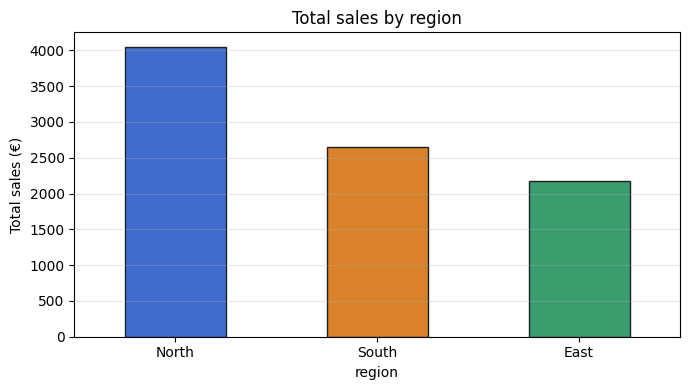

In [21]:
import matplotlib.pyplot as plt

# --- Bridging AI & Society course plot style -------------------------------
BAS_BLUE = "#416bcc"   # brand accent (lapis blue) — primary series
BAS_INK  = "#1c2025"   # brand ink — text/edges where needed
# supporting colours, chosen to sit well next to the lapis accent:
BAS_AMBER  = "#d9822b"   # secondary series / contrast
BAS_GREEN  = "#3a9e6e"   # "good" / positive
BAS_RED    = "#c8504f"   # "bad" / warnings / errors
BAS_PURPLE = "#7a5fb5"   # tertiary series
BAS_GREY   = "#8a919c"   # de-emphasised / reference lines
BAS_PALETTE = [BAS_BLUE, BAS_AMBER, BAS_GREEN, BAS_RED, BAS_PURPLE, BAS_GREY]

plt.rcParams["axes.prop_cycle"] = plt.cycler(color=BAS_PALETTE)
# ---------------------------------------------------------------------------

# Bar chart of region totals
ax = sales_by_region.plot(
    kind="bar",
    color=[BAS_BLUE, BAS_AMBER, BAS_GREEN],
    title="Total sales by region",
    figsize=(7, 4),
    rot=0,
    edgecolor=BAS_INK,
)
ax.set_ylabel("Total sales (€)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

product  Laptop  Phone  Tablet
quarter                       
Q1         1200    800     600
Q2         1350    900     750
Q3         1500    950     820


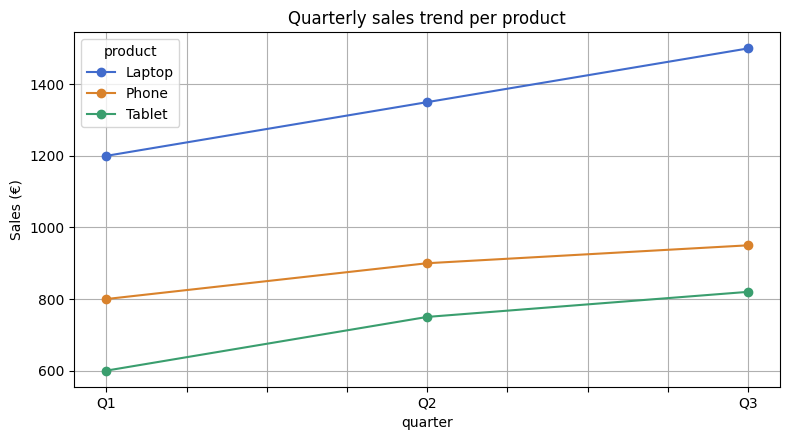

In [22]:
# Quarterly trend per product. pivot_table RESHAPES: one row per quarter,
# one column per product. Reshaping (pivot / melt / merge) belongs to
# Notebook 8 — here it is just the shortest route to one line per product.
pivot = df_sales.pivot_table(index="quarter", columns="product", values="sales", aggfunc="sum")
print(pivot)

pivot.plot(
    marker="o",
    title="Quarterly sales trend per product",
    figsize=(8, 4.5),
    grid=True,
)
plt.ylabel("Sales (€)")
plt.tight_layout()
plt.show()

## 12. The pandas patterns you'll use every day

Burn these into memory — between them they cover most of what a data scientist types before lunch:

```python
# Loading
df = pd.read_csv("data.csv")       # from a file, a URL, or a StringIO
df = pd.DataFrame(list_of_dicts)   # from JSON-shaped records

# Exploring
df.head()                          # the first rows
df.shape                           # (rows, cols)
df.dtypes                          # per-column types
df.info()                          # dtypes + non-null counts
df.describe()                      # numeric summary

# Selecting
df["col"]                          # one column   → Series
df[["col1", "col2"]]               # two columns  → DataFrame
df.loc["label"]                    # a row by label
df.iloc[0]                         # a row by position
df.loc[df["age"] > 30, "name"]     # filter rows AND pick a column

# Filtering
mask = df["score"] > 85            # a reusable boolean Series
df[mask]                           # rows above the threshold
df[~mask]                          # all the others
df[(df["score"] > 85) & (df["city"] == "Berlin")]

# Deriving and aggregating
df["ratio"] = df["score"] / df["age"]
df.sort_values("score", ascending=False)
df["city"].value_counts()
df.groupby("city")["score"].mean()
df.groupby("city").agg(n=("name", "count"), avg=("score", "mean"))

# Saving
df.to_csv("out.csv", index=False)
```


## 🧪 Practice exercises

For the next exercises we'll use a small "sales transactions" DataFrame.

In [23]:
rng = np.random.default_rng(42)
n = 50

sales_data = pd.DataFrame({
    "transaction_id": range(1, n + 1),
    "product"       : rng.choice(["Laptop", "Phone", "Tablet", "Watch"], n),
    "region"        : rng.choice(["North", "South", "East", "West"], n),
    "quarter"       : rng.choice(["Q1", "Q2", "Q3", "Q4"], n),
    "amount"        : rng.integers(100, 2000, n).astype(float),
    "customer_age"  : rng.integers(18, 70, n),
})
sales_data.head()

,transaction_id,product,region,quarter,amount,customer_age
0,1,Laptop,West,Q4,1725.0,37
1,2,Watch,North,Q1,634.0,65
2,3,Tablet,South,Q4,1843.0,43
3,4,Phone,South,Q1,657.0,54
4,5,Phone,South,Q4,925.0,41


### Exercise 7.1 — Basic exploration

1. Print the **shape** and **dtypes**.
2. Print the **mean** and **median** of `amount`.
3. Show how many transactions there were in each `region`.

In [24]:
# Your code here  👇


<details>
<summary>💡 Click to reveal the solution</summary>

```python
print(f"shape  = {sales_data.shape}")
print(f"\ndtypes:\n{sales_data.dtypes}")

print(f"\nmean amount   = {sales_data['amount'].mean():.2f}")
print(f"median amount = {sales_data['amount'].median():.2f}")

print("\nTransactions per region:")
print(sales_data['region'].value_counts())
```
</details>

### Exercise 7.2 — Label vs position

`sales_data` has a `transaction_id` column running from 1 to 50 — a label that is off by one from each row's position.

1. Make `transaction_id` the index with `.set_index(...)` and call the result `tx`.
2. Print the row for **transaction 7** using `.loc`, and the row at **position 7** using `.iloc`. Which transaction is the second one, and why?
3. Print the `amount` of transaction 7 with a single `.loc[...]` call (row label *and* column label).
4. Compare `tx.loc[5:10]` with `tx.iloc[5:10]`: how many rows does each return, and which transactions?


In [25]:
# Your code here  👇



<details>
<summary>💡 Click to reveal the solution</summary>

```python
tx = sales_data.set_index("transaction_id")

# 2) label 7 vs position 7
print(f".loc[7]  is transaction {tx.loc[7].name}")     # 7
print(f".iloc[7] is transaction {tx.iloc[7].name}")    # 8
print(tx.loc[7])

# 3) row label and column label in one call
print(f"\namount of transaction 7: {tx.loc[7, 'amount']}")

# 4) label slices include the endpoint, position slices do not
print(f"\ntx.loc[5:10]  -> {len(tx.loc[5:10])} rows: {tx.loc[5:10].index.tolist()}")
print(f"tx.iloc[5:10] -> {len(tx.iloc[5:10])} rows: {tx.iloc[5:10].index.tolist()}")
```

**Why.** The labels start at 1 and the positions start at 0, so position 7 is the *eighth* row — transaction 8. That single off-by-one is the most common `loc`/`iloc` bug in real code, and it is invisible on a default index.

`tx.loc[5:10]` returns **6** rows (transactions 5, 6, 7, 8, 9, 10) because a label slice includes its endpoint. `tx.iloc[5:10]` returns **5** rows (positions 5–9, i.e. transactions 6–10) because a position slice is half-open like `range(5, 10)`. Same two numbers, different answers — always ask yourself which of the two you are handing pandas.

</details>


### Exercise 7.3 — Filtering

Find all transactions where the **amount is at least 1500 AND the customer is at least 40 years old**. How many are there? What's their average amount?

In [26]:
# Your code here  👇


<details>
<summary>💡 Click to reveal the solution</summary>

```python
big_old = sales_data[(sales_data["amount"] >= 1500) & (sales_data["customer_age"] >= 40)]

print(f"Matching rows : {len(big_old)}")
print(f"Mean amount   : €{big_old['amount'].mean():,.2f}")
big_old.head()
```
</details>

### Exercise 7.4 — Group-by

For each `product`, compute:

1. Total sales `amount`.
2. Number of transactions.
3. The region with the highest *total* amount (think: groupby on two columns).

Tip: `df.groupby(["product", "region"])["amount"].sum()` returns a stacked Series — combine with `.idxmax()` or `.sort_values()`.

In [27]:
# Your code here  👇


<details>
<summary>💡 Click to reveal the solution</summary>

```python
# 1 & 2: per-product summary
summary = sales_data.groupby("product").agg(
    total_sales =("amount", "sum"),
    n_transactions=("amount", "count"),
)
print(summary)

# 3: top region per product
grouped = sales_data.groupby(["product", "region"])["amount"].sum()
print("\nTop region per product:")
print(grouped.groupby(level=0).idxmax())   # tuple (product, region)
```
</details>

### Exercise 7.5 — Visual exploration

Create two plots:

1. A **bar chart** of total sales per `region`.
2. A **histogram** of `customer_age` with 10 bins.

Add titles and axis labels.

In [28]:
# Your code here  👇


<details>
<summary>💡 Click to reveal the solution</summary>

```python
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1) Bar chart
sales_data.groupby("region")["amount"].sum().plot(
    kind="bar", ax=axes[0], color=BAS_BLUE, edgecolor=BAS_INK
)
axes[0].set_title("Total sales per region")
axes[0].set_ylabel("Total sales (€)")
axes[0].tick_params(axis="x", rotation=0)
axes[0].grid(axis="y", alpha=0.3)

# 2) Histogram
sales_data["customer_age"].plot(
    kind="hist", bins=10, ax=axes[1], color=BAS_AMBER, edgecolor=BAS_INK
)
axes[1].set_title("Customer age distribution")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()
```
</details>

### Exercise 7.6 — Debug me 🐞

The cell below should print the **average amount in each region**, but it raises an error. Uncomment the line, run it to see the error, then fix it.

In [29]:
# Buggy — uncomment the line below, run it, read the error, then fix it:
# print(sales_data.groupby(region).mean(amount))


<details>
<summary>💡 Click to reveal the solution</summary>

Two issues:

1. `region` and `amount` need to be **strings** (column names), not bare identifiers.
2. `.mean(amount)` is not how you pick a column — `.mean()` takes no positional column name.

```python
# Correct:
print(sales_data.groupby("region")["amount"].mean())
```

Or, using `.agg`:

```python
print(sales_data.groupby("region").agg(avg=("amount", "mean")))
```
</details>

## 🧠 Key takeaways

1. A **DataFrame** is a labelled table; a **Series** is one column — a labelled NumPy array underneath.
2. Inspect every new dataset with `df.head() / .shape / .dtypes / .info() / .describe()`, and actually *read* the non-null counts.
3. Select columns with `df["col"]` or `df[["col1", "col2"]]`. Select rows with **`.loc[label]`** or **`.iloc[position]`**: `.loc` follows the labels through any sort and **includes** the endpoint of a slice; `.iloc` follows the current order and **excludes** it. Default to `.loc`.
4. **Boolean masks** are ordinary objects — `mask = df["score"] > 85`, then `df[mask]`, `df[~mask]`, `mask.sum()`, `df.loc[mask, ["name"]]`. Combine with `&` and `|`, and parenthesise each condition.
5. Assigning to `df["new"]` creates a column; the arithmetic is vectorised, so no loops.
6. **`groupby` → aggregation** is the workhorse of analysis: split by key, apply (`mean`, `sum`, `count`, `.agg(...)`), combine into a Series or DataFrame indexed by the key.
7. `pd.read_csv()` loads a table in one line and `df.to_csv()` writes it back; `pd.DataFrame(list_of_dicts)` does the same for the JSON-shaped records of Notebook 4 — and `groupby` replaces the hand-written grouping loops you wrote there.
8. `df.plot(...)` is the fast path to an exploratory chart.
9. What is deliberately *not* here: missing values, duplicates and wrong dtypes go to **[Notebook 8](08_data_cleaning_preprocessing.ipynb)**, serious chart craft to **[Notebook 9](09_visualization_matplotlib.ipynb)**, and the question of *which* questions to ask a new dataset to **[Notebook 10](10_exploratory_data_analysis.ipynb)**.

## ✅ Self-assessment

- [ ] Build a DataFrame from a `dict` of lists, and from a list of dicts.
- [ ] Select a single column and several columns.
- [ ] Explain the difference between `.loc` and `.iloc`, including the slice endpoint, without looking it up.
- [ ] Filter rows on one and two conditions, and invert a mask with `~`.
- [ ] Add a new computed column.
- [ ] Compute the mean / total / count grouped by a category.
- [ ] Render a bar or line chart from a Series or DataFrame.

## 🚀 Next step

Real datasets are never as tidy as the ones above: values go missing, rows get duplicated, numbers arrive as text. Continue with **[Notebook 8 — Data Cleaning and Preprocessing](08_data_cleaning_preprocessing.ipynb)** to make messy data usable, then **[Notebook 9 — Visualisation with Matplotlib](09_visualization_matplotlib.ipynb)** and **[Notebook 10 — Exploratory Data Analysis](10_exploratory_data_analysis.ipynb)** to explore it properly.
